In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("/deliveries.csv.zip")

# Dataset size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

Rows: 260920
Columns: 17

Column Names:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

First 5 Rows:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
# Check data types
print("DATA TYPES:")
print(df.dtypes)

# Check missing values
print("\nMISSING VALUES:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDUPLICATE ROWS:")
print(df.duplicated().sum())

DATA TYPES:
match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object

MISSING VALUES:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

DUPLICATE ROWS:
0


In [5]:
print("BASIC STATISTICS")
display(df.describe())

BASIC STATISTICS


,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [6]:
top_batsmen = (
    df.groupby("batter")["batsman_runs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Run Scorers:")
display(top_batsmen)

Top 10 Run Scorers:


,batsman_runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


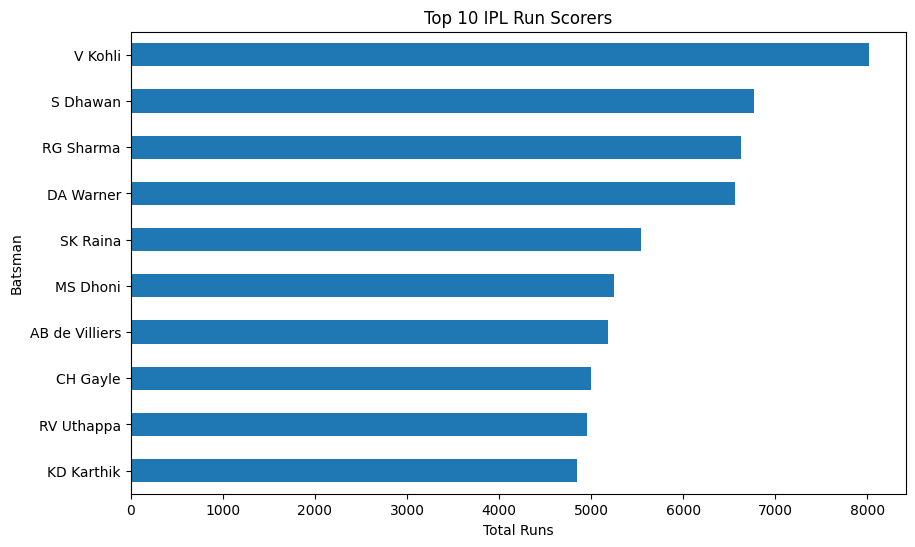

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_batsmen.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")

plt.show()

In [8]:
# Bowling dismissals (excluding run-outs and other non-bowler dismissals)

bowler_wickets = (
    df[
        (df["is_wicket"] == 1) &
        (~df["dismissal_kind"].isin([
            "run out",
            "retired hurt",
            "retired out",
            "obstructing the field"
        ]))
    ]
    .groupby("bowler")["is_wicket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Wicket Takers:")
display(bowler_wickets)

Top 10 Wicket Takers:


,is_wicket
bowler,
YS Chahal,205
PP Chawla,192
DJ Bravo,183
B Kumar,181
R Ashwin,180
SP Narine,180
A Mishra,174
SL Malinga,170
JJ Bumrah,168


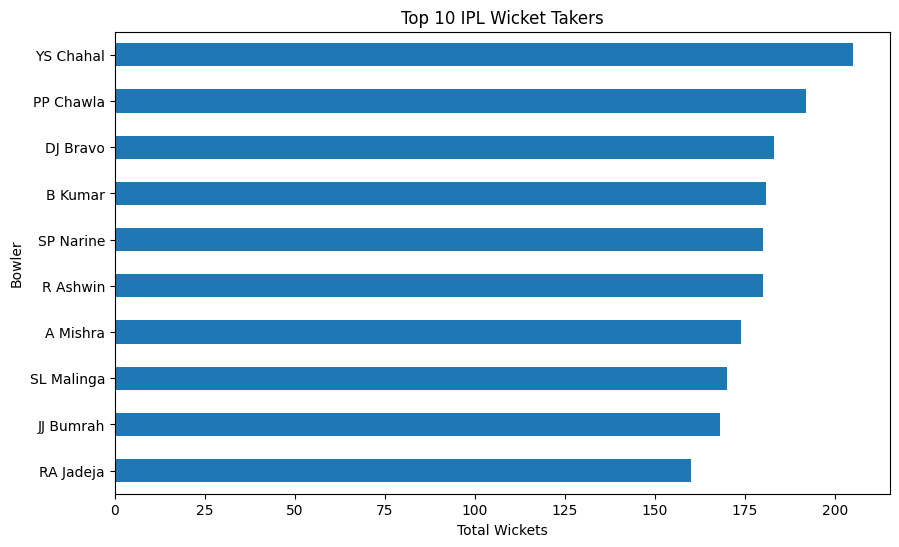

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bowler_wickets.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Wicket Takers")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")

plt.show()

In [10]:
team_runs = (
    df.groupby("batting_team")["total_runs"]
      .sum()
      .sort_values(ascending=False)
)

print("Team-wise Total Runs:")
display(team_runs)

Team-wise Total Runs:


,total_runs
batting_team,
Mumbai Indians,42176
Kolkata Knight Riders,39331
Chennai Super Kings,38629
Royal Challengers Bangalore,37692
Rajasthan Royals,34747
Kings XI Punjab,30064
Sunrisers Hyderabad,29071
Delhi Daredevils,24296
Delhi Capitals,14900


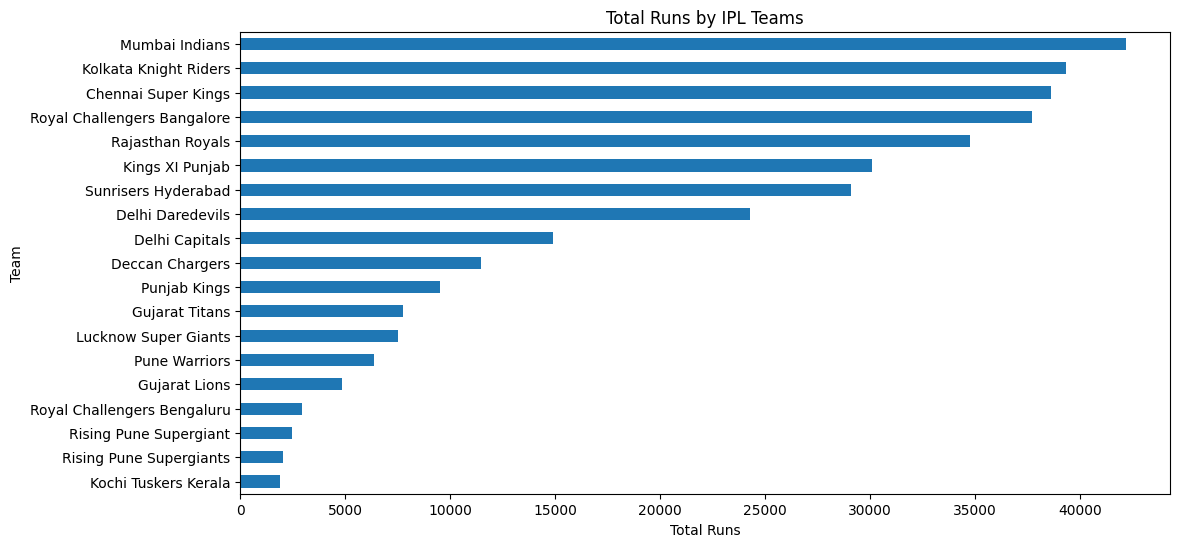

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

team_runs.sort_values().plot(kind="barh")

plt.title("Total Runs by IPL Teams")
plt.xlabel("Total Runs")
plt.ylabel("Team")

plt.show()

In [13]:
match_runs = (
    df.groupby("match_id")["total_runs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Highest Scoring Matches:")
display(match_runs)

Top 10 Highest Scoring Matches:


,total_runs
match_id,
1426268,549
1422126,523
1426280,523
1426281,504
419137,469
1426273,465
1136604,459
1359512,458
1082641,453


In [14]:
player_stats = (
    df.groupby("batter")
      .agg(
          runs=("batsman_runs", "sum"),
          balls=("batsman_runs", "count")
      )
)

# Minimum 100 balls faced
player_stats = player_stats[player_stats["balls"] >= 100]

# Strike Rate
player_stats["strike_rate"] = (
    player_stats["runs"] / player_stats["balls"]
) * 100

top_strike_rate = (
    player_stats.sort_values("strike_rate", ascending=False)
                .head(10)
)

print("Top 10 Players by Strike Rate (minimum 100 balls):")
display(top_strike_rate)

Top 10 Players by Strike Rate (minimum 100 balls):


,runs,balls,strike_rate
batter,,,
J Fraser-McGurk,330,150,220.000000
WG Jacks,230,133,172.932331
PD Salt,653,385,169.610390
T Stubbs,405,239,169.456067
TM Head,772,458,168.558952
AD Russell,2488,1515,164.224422
BCJ Cutting,238,146,163.013699
H Klaasen,993,613,161.990212
Ramandeep Singh,170,106,160.377358


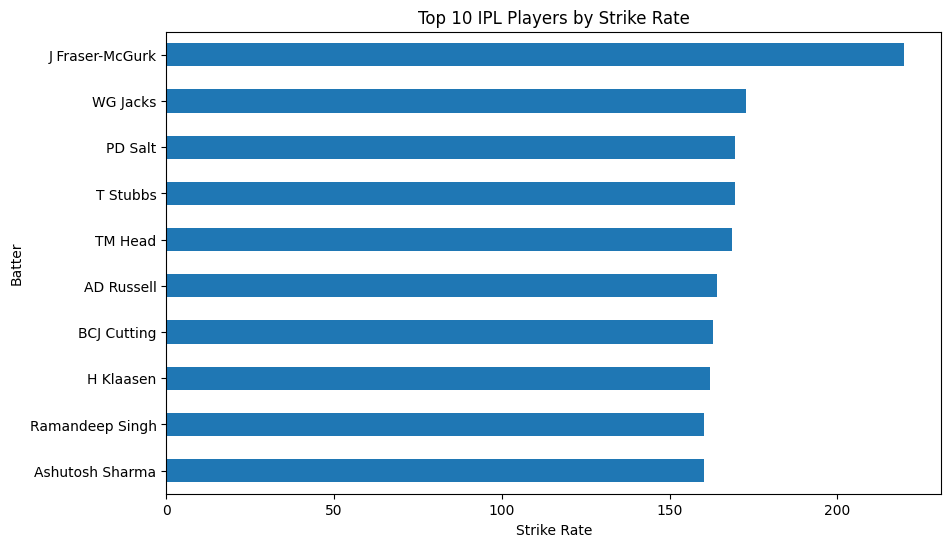

In [15]:
plt.figure(figsize=(10, 6))

top_strike_rate["strike_rate"].sort_values().plot(kind="barh")

plt.title("Top 10 IPL Players by Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.show()

In [16]:
# Legal deliveries bowled by each bowler
legal_balls = df[
    ~df["extras_type"].isin(["wides", "noballs"])
]

bowling_stats = (
    legal_balls.groupby("bowler")
    .agg(
        runs_conceded=("total_runs", "sum"),
        legal_balls=("total_runs", "count")
    )
)

# Minimum 300 legal balls
bowling_stats = bowling_stats[bowling_stats["legal_balls"] >= 300]

# Economy rate
bowling_stats["economy"] = (
    bowling_stats["runs_conceded"] /
    (bowling_stats["legal_balls"] / 6)
)

top_economical_bowlers = (
    bowling_stats.sort_values("economy")
    .head(10)
)

print("Top 10 Bowlers by Economy Rate (minimum 300 legal balls):")
display(top_economical_bowlers)

Top 10 Bowlers by Economy Rate (minimum 300 legal balls):


,runs_conceded,legal_balls,economy
bowler,,,
A Kumble,1050,965,6.528497
GD McGrath,360,324,6.666667
M Muralitharan,1700,1528,6.675393
SP Narine,4580,4081,6.733644
J Yadav,438,390,6.738462
DW Steyn,2453,2182,6.745188
MJ Santner,413,366,6.770492
RE van der Merwe,503,443,6.812641
DL Vettori,886,777,6.841699


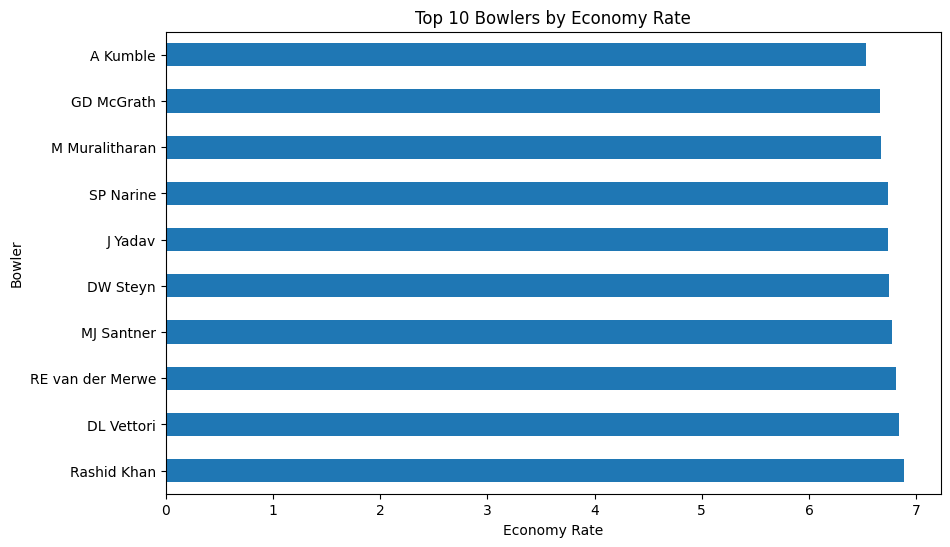

In [17]:
plt.figure(figsize=(10, 6))

top_economical_bowlers["economy"].sort_values(ascending=False).plot(kind="barh")

plt.title("Top 10 Bowlers by Economy Rate")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.show()

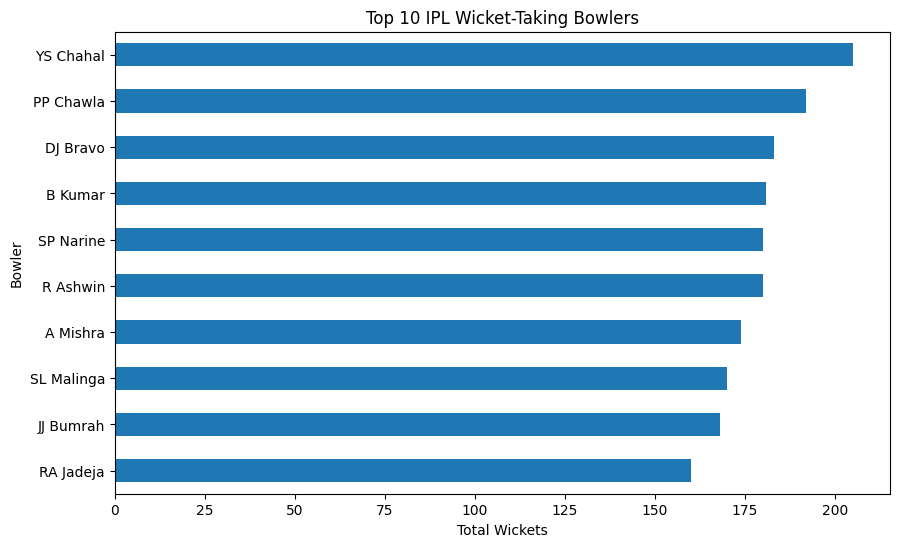

In [18]:
plt.figure(figsize=(10, 6))

bowler_wickets.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Wicket-Taking Bowlers")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")

plt.show()

In [19]:
top_batter_summary = player_stats.loc[
    top_batsmen.index,
    ["runs", "balls", "strike_rate"]
].sort_values("runs", ascending=False)

print("Top Batters Performance Summary:")
display(top_batter_summary)

Top Batters Performance Summary:


,runs,balls,strike_rate
batter,,,
V Kohli,8014,6236,128.511867
S Dhawan,6769,5483,123.454313
RG Sharma,6630,5183,127.918194
DA Warner,6567,4849,135.429986
SK Raina,5536,4177,132.535312
MS Dhoni,5243,3947,132.835065
AB de Villiers,5181,3487,148.580442
CH Gayle,4997,3516,142.121729
RV Uthappa,4954,3927,126.152279


In [20]:
print("KEY FINDINGS")
print("1. Identified the top 10 IPL run scorers.")
print("2. Identified the top 10 wicket-taking bowlers.")
print("3. Analyzed total runs scored by each team.")
print("4. Compared players using strike rate.")
print("5. Compared bowlers using economy rate.")
print("6. Checked missing values, data types, duplicates, and basic statistics.")

KEY FINDINGS
1. Identified the top 10 IPL run scorers.
2. Identified the top 10 wicket-taking bowlers.
3. Analyzed total runs scored by each team.
4. Compared players using strike rate.
5. Compared bowlers using economy rate.
6. Checked missing values, data types, duplicates, and basic statistics.
